# Deber grupal · Semana 4 · «Dos fuentes entrando»
**Programación Aplicada a la Inteligencia de Mercados · UIDE · Juan Carlos Correa / Docente**

Este deber es el **Hito 1** del Observatorio: su observatorio trae datos de **dos fuentes**. **Vale 6 puntos.**

| | Grupo 1 · El bolsillo | Grupo 2 · El crédito | Grupo 3 · Quién crece |
|---|---|---|---|
| **Fuente 1** | Su canasta de 20 productos en Tía | Recaudación del SRI · 5 provincias | Recaudación del SRI · 5 actividades |
| **Fuente 2** | Banco Mundial: inflación y consumo | Banco Mundial: crédito y morosidad | Banco Mundial: PIB y servicios |

**Los robots ya están escritos. Lo que ustedes aportan son las decisiones:** qué vigilar, comprobar que los datos son ciertos y explicar qué significan.

### El botón que van a usar
Cada paso tiene **una celda gris con un título**. A la izquierda del título está el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> (un círculo con un triángulo que apunta a la derecha). **Pulsar ese botón hace el paso.**

![Así se ve la celda de un paso: a la izquierda el botón, a la derecha los recuadros para escribir](https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/celda_paso.png)

- En este cuaderno, el símbolo <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> significa siempre y solamente **ese botón**.
- Si la celda tiene **recuadros para escribir** (a la derecha del título), primero escriben en ellos y después pulsan <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.
- Cuando el paso termina, aparece una línea que empieza con **✅**.
- La primera vez, Colab avisa *«Este notebook no fue creado por Google»*: pulsen **Ejecutar de todos modos**.

### El camino, de un vistazo
| Paso | Qué hacen |
|:---:|---|
| **0** | El cuaderno del equipo: nombre y compartir |
| **1** | Quiénes somos |
| **2** | Qué vamos a vigilar |
| **3** | Traer la Fuente 1 |
| **4** | Traer la Fuente 2 (Banco Mundial) |
| **5** | Comprobar a mano |
| **6** | Interpretar las dos fuentes juntas |
| **7** | Quién hizo qué |
| **8** | Guardar y entregar |

Cada paso usa lo que salió del anterior: **háganlos en orden.** Todos en el equipo deben poder hacer cualquier paso.

## PASO 0 · El cuaderno del equipo

**🔗 Lo que ya tienen:** este cuaderno abierto en Colab. Una persona del equipo lo bajó de Canvas (Semana 4) y lo subió a Colab (menú **Archivo**, opción **Subir cuaderno**). Colab ya lo guardó en su Google Drive.

**🎯 En este paso:** le ponen nombre y lo comparten con el equipo, para trabajar todos en el mismo cuaderno.

**👆 Qué hacen:**
1. Hagan clic en el nombre (arriba a la izquierda) y escriban **`DEBER4_G0X`** (con su número de grupo). Pulsen **Enter**.
2. Arriba a la derecha, botón **Compartir**: escriban los correos de los integrantes, elijan **Editor** y pulsen **Enviar**.

**👀 Qué deben ver:** el nombre `DEBER4_G0X.ipynb` arriba a la izquierda.

**🧩 Lo que se llevan al Paso 1:** el cuaderno del equipo, compartido.

## PASO 1 · Quiénes somos

**🔗 Lo que ya tienen:** la copia del equipo (Paso 0).

**🎯 En este paso:** le dicen al cuaderno qué grupo son. El cuaderno prepara sus herramientas y sus tres robots.

**👆 Qué hacen:** 1. En la lista **GRUPO** elijan su grupo.
2. En **INTEGRANTES** escriban los nombres del equipo, separados por comas.
3. Pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué deben ver:** su grupo, sus dos fuentes y, al final, `✅ Paso 1 listo`. Tarda unos 20 segundos la primera vez.

**🧩 Lo que se llevan al paso siguiente:** el grupo y sus dos fuentes.

In [ ]:
#@title PASO 1 · Quiénes somos { display-mode: "form" }
#@markdown Elijan su grupo, escriban los integrantes y pulsen el botón redondo
GRUPO = "Grupo 1 · El bolsillo del ecuatoriano"  #@param ["Grupo 1 · El bolsillo del ecuatoriano", "Grupo 2 · El crédito del país", "Grupo 3 · Quién crece y quién se muere"]
INTEGRANTES = "ZARA TIGUA, GABRIEL CUPACAN, NAYELI LIMA Y SARA SÁNCHEZ" #@param {type:"string"}
import json, os, subprocess
subprocess.run(["pip", "install", "-q", "tenacity"], capture_output=True)
os.makedirs("data", exist_ok=True)
open("tienda.py", "w", encoding="utf-8").write(r'''# ─────────────────────────────────────────────────────────────
#  GRUPO 1 · El bolsillo del ecuatoriano · FUENTE 1: la canasta de Tía
#  La canasta la decide el grupo (paso G2): 20 fichas de producto de tia.com.ec.
#  Cumple la evidencia de la semana 3: un robot que MONITOREA precios de un e-commerce ecuatoriano.
# ─────────────────────────────────────────────────────────────
import os, re, sys, time, random, datetime, urllib.robotparser, requests, pandas as pd
from zoneinfo import ZoneInfo
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

TIENDA = os.environ.get("TIA_BASE", "https://www.tia.com.ec")
if "--simular-caida" in sys.argv:
    TIENDA = "http://10.255.255.1"                      # las 3 de la mañana: la tienda no contesta
CANASTA = [tuple(x.split("|", 1)) for x in open("canasta.txt", encoding="utf-8").read().splitlines() if "|" in x]   # la eligió el grupo
AHORA = datetime.datetime.now(ZoneInfo("America/Guayaquil")).strftime("%Y-%m-%d %H:%M")
FOTO, HISTORIA = "data/canasta_tia.csv", "data/historico_canasta_tia.csv"
AGENTE = "ObservatorioUIDE/1.0 (proyecto academico)"
os.makedirs("data", exist_ok=True)

def bitacora(m):                                        # REGLA 5
    open("data/bitacora.log", "a", encoding="utf-8").write(f"{AHORA} | tienda | {m}\n")

@retry(stop=stop_after_attempt(3), wait=wait_exponential(min=1, max=8),        # REGLA 2
       retry=retry_if_exception_type((requests.ConnectionError, requests.Timeout)), reraise=True)
def pedir(url):
    return requests.get(url, timeout=2 if "10.255" in url else 20, headers={"User-Agent": AGENTE})  # REGLA 1

# Antes de entrar, leemos el cartel de la tienda (robots.txt)
cartel = urllib.robotparser.RobotFileParser()
try:
    cartel.parse(pedir(TIENDA + "/robots.txt").text.splitlines())
    print("🪧 robots.txt leído: la tienda dice qué se puede y qué no.")
except Exception as e:
    print(f"✖ No se pudo leer el robots.txt ({type(e).__name__}).")

filas, fallos = [], 0
for nombre, ruta in CANASTA:
    url = TIENDA + ruta if ruta.startswith("/") else ruta.replace("https://www.tia.com.ec", TIENDA)
    if cartel.default_entry and not cartel.can_fetch(AGENTE, url):
        print(f"  ⛔ {nombre}: el robots.txt no lo permite. Se salta."); continue
    if fallos >= 3:                                      # INTERRUPTOR
        print("⚡ Interruptor abierto: 3 fallos seguidos. Se detiene hasta la próxima ejecución."); break
    try:
        r = pedir(url)
        precio = re.search(r'product:price:amount" content="([\d.]+)"', r.text)
        if r.status_code == 200 and precio:              # REGLA 3 · desconfía del 200
            filas.append({"producto": nombre, "precio_usd": round(float(precio.group(1)), 2),
                          "url": url, "fecha_captura": AHORA, "fuente": "Tía · ficha de producto"})
            print(f"  ✔ {nombre:<26} USD {float(precio.group(1)):.2f}"); fallos = 0
        else:
            print(f"  ⚠ {nombre}: código {r.status_code}, sin precio en la ficha"); fallos += 1
    except Exception as e:
        print(f"  ✖ {nombre}: no contestó ({type(e).__name__})"); fallos += 1
    time.sleep(random.uniform(1.5, 3))                   # pausa humana

tabla = pd.DataFrame(filas)
if len(tabla) >= max(1, int(0.75 * len(CANASTA))):     # al menos 3 de cada 4 productos para que la canasta valga
    tabla.to_csv(FOTO, index=False)
    tabla.to_csv(HISTORIA, mode="a", index=False, header=not os.path.exists(HISTORIA))
    bitacora(f"OK · {len(tabla)} de {len(CANASTA)} productos · canasta USD {tabla.precio_usd.sum():.2f}")
    print(f"\n✔ LISTO: {len(tabla)} de {len(CANASTA)} productos · la canasta cuesta hoy USD {tabla.precio_usd.sum():.2f}")
elif os.path.exists(FOTO):                               # REGLA 4
    bitacora(f"FALLÓ · solo {len(tabla)} productos · se conserva la canasta anterior")
    print(f"\n⚠ Solo llegaron {len(tabla)} productos. NO se pisa la canasta anterior [RESPALDO].")
else:
    bitacora(f"FALLÓ · solo {len(tabla)} productos · sin respaldo")
    print(f"\n✖ Solo llegaron {len(tabla)} productos y no hay canasta anterior.")
''')
open("sri.py", "w", encoding="utf-8").write(r'''# ─────────────────────────────────────────────────────────────
#  GRUPOS 2 y 3 · FUENTE 1: recaudación mensual del SRI
#  Grupo 2 • por PROVINCIA  ·  Grupo 3 • por ACTIVIDAD ECONÓMICA (sección CIIU)
#  Plan A: pedir el dato EN VIVO al portal de datos abiertos (API CKAN) y al SRI.
#  Plan B: si el portal no deja entrar (pasa desde Colab: el portal de Ecuador
#          bloquea a los servidores de fuera del país), se usa el RESPALDO del
#          profesor, sacado del mismo archivo oficial del SRI el 30-sep-2026.
# ─────────────────────────────────────────────────────────────
import os, sys, io, json, datetime, unicodedata, requests, pandas as pd
from zoneinfo import ZoneInfo
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

CKAN = os.environ.get("CKAN_BASE", "https://www.datosabiertos.gob.ec/api/3/action")
RESPALDO = os.environ.get("SRI_RESPALDO", "https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/respaldo_sri.csv")
SIMULAR_CAIDA = "--simular-caida" in sys.argv
if SIMULAR_CAIDA:
    CKAN = "http://10.255.255.1"
ESPERA = 2 if SIMULAR_CAIDA else 20
NAVEGADOR = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0 Safari/537.36"}
GRUPO = json.load(open("grupo.json"))["grupo"]
CORTE = "PROVINCIA" if GRUPO == 2 else "ACTIVIDAD"
ANIO = datetime.date.today().year                        # este año contra el anterior
AHORA = datetime.datetime.now(ZoneInfo("America/Guayaquil")).strftime("%Y-%m-%d %H:%M")
ARCHIVO, MENSUAL = "data/sri_resumen.csv", "data/sri_total_mensual.csv"
os.makedirs("data/crudo", exist_ok=True)
CIIU = {"A": "Agricultura y pesca", "B": "Minas y petróleo", "C": "Manufactura", "D": "Electricidad y gas",
        "E": "Agua y residuos", "F": "Construcción", "G": "Comercio", "H": "Transporte", "I": "Alojamiento y comidas",
        "J": "Información y comunicación", "K": "Finanzas y seguros", "L": "Inmobiliarias", "M": "Actividades profesionales",
        "N": "Servicios administrativos", "O": "Administración pública", "P": "Enseñanza", "Q": "Salud",
        "R": "Artes y recreación", "S": "Otros servicios", "T": "Hogares", "U": "Organismos extraterritoriales"}
SIGNIFICADO = {200: "todo bien", 403: "prohibido: el portal no deja entrar desde aquí", 404: "no existe",
               429: "demasiadas preguntas", 500: "el portal está dañado"}

def bitacora(m):
    open("data/bitacora.log", "a", encoding="utf-8").write(f"{AHORA} | sri | {m}\n")

class SinPermiso(Exception):
    pass

@retry(stop=stop_after_attempt(3), wait=wait_exponential(min=1, max=8),
       retry=retry_if_exception_type((requests.ConnectionError, requests.Timeout)), reraise=True)
def preguntar_ckan(anio):
    """Le pregunta a la API del portal: ¿dónde está el CSV de recaudación de ese año?"""
    r = requests.get(f"{CKAN}/package_search", params={"q": f"recaudacion impuestos {anio}", "rows": 30},
                     timeout=ESPERA, headers=NAVEGADOR)
    print(f"  ← el portal respondió {r.status_code}: {SIGNIFICADO.get(r.status_code, 'respuesta rara')}")
    if r.status_code != 200:                             # REGLA 3 · sin 200 no hay JSON: no seguimos a ciegas
        raise SinPermiso(f"código {r.status_code}")
    for p in r.json()["result"]["results"]:
        if p["name"].endswith(str(anio)) and "sri" in (p.get("organization") or {}).get("title", "").lower():
            return next(x["url"] for x in p["resources"] if x["format"].upper() == "CSV")
    return None

def descargar(url, destino):
    if os.path.exists(destino):                          # caché: no se pide dos veces lo mismo
        print(f"  📦 Ya estaba descargado: {destino}"); return
    print(f"  ⬇ Descargando {url.split('/')[-1]} (cerca de 100 MB, 1–2 minutos)…")
    with requests.get(url, stream=True, timeout=60, headers=NAVEGADOR) as r:
        if r.status_code != 200:
            raise SinPermiso(f"descarga con código {r.status_code}")
        with open(destino + ".parcial", "wb") as f:
            for trozo in r.iter_content(1 << 20):
                f.write(trozo)
    os.replace(destino + ".parcial", destino)

def en_vivo():
    """PLAN A. Devuelve una tabla ANIO | MES | CLAVE | VALOR_RECAUDADO."""
    partes = []
    for anio in (ANIO - 1, ANIO):
        print(f"• Año {anio}: buscando el archivo en datosabiertos.gob.ec")
        url = preguntar_ckan(anio)
        if not url:
            raise SinPermiso(f"el portal no tiene el archivo de {anio}")
        destino = f"data/crudo/sri_recaudacion_{anio}.csv"
        descargar(url, destino)
        col = "PROVINCIA" if CORTE == "PROVINCIA" else "CODIGO_OPERA_FAMILIA"
        d = pd.read_csv(destino, sep="|", decimal=",", encoding="latin-1", usecols=["ANIO", "MES", col, "VALOR_RECAUDADO"])
        d["MES"] = d["MES"].astype(str).str[:2].astype(int)
        partes.append(d.rename(columns={col: "CLAVE"}))
    return pd.concat(partes), "SRI · Recaudación mensual (en vivo, vía API CKAN)"

def respaldo():
    """PLAN B. El mismo dato oficial del SRI, ya resumido por el profesor."""
    print("\n• Plan B: traigo el RESPALDO del profesor (archivo oficial del SRI, capturado el 30-sep-2026)")
    r = requests.get(RESPALDO, timeout=30) if RESPALDO.startswith("http") else None
    texto = r.text if r is not None else open(RESPALDO, encoding="utf-8").read()
    if r is not None and r.status_code != 200:
        raise SinPermiso(f"respaldo con código {r.status_code}")
    d = pd.read_csv(io.StringIO(texto), sep="|", dtype={"CLAVE": str})
    d = d[d["CORTE"] == CORTE].drop(columns="CORTE")
    return d, "SRI · Recaudación mensual (respaldo del profesor, 30-sep-2026)"

try:
    try:
        df, fuente = en_vivo()
        de_respaldo = False
    except Exception as e:
        print(f"  ✖ En vivo no se pudo: {e}")
        if SIMULAR_CAIDA:                                # en la prueba del apagón no hay plan B: queremos ver el fallo
            raise
        df, fuente = respaldo()
        de_respaldo = True
    df = df[df["ANIO"].isin([ANIO - 1, ANIO])]
    ultimo_mes = int(df.loc[df["ANIO"] == ANIO, "MES"].max())
    df = df[df["MES"] <= ultimo_mes]                      # comparamos los mismos meses en ambos años
    (df[df["ANIO"] == ANIO].groupby("MES")["VALOR_RECAUDADO"].sum() / 1e6).round(1) \
        .rename("millones_usd").to_csv(MENSUAL)          # para verificar a mano en el paso G8
    t = df.pivot_table(index="CLAVE", columns="ANIO", values="VALOR_RECAUDADO", aggfunc="sum").fillna(0)
    t = t[t.iloc[:, 0] > 0]
    t.columns = [f"recaudado_{c}" for c in t.columns]
    t["variacion_pct"] = ((t.iloc[:, 1] / t.iloc[:, 0] - 1) * 100).round(1)
    if CORTE == "ACTIVIDAD":
        t = t[t.index.isin(list(CIIU))]
        t.index = [f"{i} · {CIIU[i]}" for i in t.index]
    else:
        t = t[t.index != "NO TIENE"]
    t.index.name = "provincia" if GRUPO == 2 else "actividad"
    elegidas = json.load(open("eleccion.json"))          # las 5 que decidió vigilar el grupo
    sin_tilde = lambda x: unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode().upper().strip()
    t["vigilada"] = [any(sin_tilde(i).startswith(sin_tilde(e)) for e in elegidas) for i in t.index]
    t = t.sort_values("variacion_pct", ascending=False).reset_index()
    t["periodo"] = f"enero–mes {ultimo_mes} · {ANIO} vs {ANIO - 1}"
    t["fecha_captura"], t["fuente"] = AHORA, fuente
    if len(t) < 5 or t["vigilada"].sum() < 5:             # REGLA 3 · desconfía
        raise RuntimeError(f"algo no cuadra: {len(t)} filas y {t['vigilada'].sum()} de 5 vigiladas")
    t.to_csv(ARCHIVO, index=False)
    if de_respaldo:
        bitacora(f"FALLÓ en vivo · se usó el RESPALDO del profesor · {len(t)} filas · meses 1-{ultimo_mes}")
        print(f"\n⚠ En vivo no se pudo, uso el RESPALDO: {len(t)} filas (enero a mes {ultimo_mes}, {ANIO} contra {ANIO - 1}).")
        print("  Es el mismo archivo oficial del SRI. En el PDF anótenlo: fuente = respaldo del profesor.")
    else:
        bitacora(f"OK · {len(t)} filas · meses 1-{ultimo_mes}")
    print(f"\n✔ LISTO: {len(t)} filas en {ARCHIVO}")
except Exception as e:
    print(f"  ✖ Falló: {e}")
    if os.path.exists(ARCHIVO):                           # REGLA 4
        bitacora("FALLÓ · se conserva el resumen anterior")
        print("\n⚠ NO se pisa el resumen anterior [RESPALDO].")
    else:
        bitacora("FALLÓ · sin respaldo")
        print("\n✖ No hay resumen anterior. Avisen al profesor con una captura de esta pantalla.")
''')
open("ventanilla.py", "w", encoding="utf-8").write(r'''# ─────────────────────────────────────────────────────────────
#  LA VENTANILLA · cliente resiliente de 2 APIs (requests + tenacity)
#  API 1: Banco Mundial (lo que pasó)   ·   API 2: FMI (lo que se proyecta)
#  Observatorio 0 · Clase 4 · UIDE · Juan Carlos Correa
#  Pregunta del cliente: ¿hay más o menos crédito en la economía para comprar vivienda,
#  y cómo viene la economía para el año del lanzamiento?
# ─────────────────────────────────────────────────────────────
import sys, os, json, datetime, time, requests, pandas as pd
from zoneinfo import ZoneInfo
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

BM  = os.environ.get("BM_BASE",  "https://api.worldbank.org/v2")
FMI = os.environ.get("FMI_BASE", "https://www.imf.org/external/datamapper/api/v1")
PREGUNTAS_BM  = {"FS.AST.PRVT.GD.ZS": "Crédito al sector privado (% del PIB)", "FP.CPI.TOTL.ZG": "Inflación anual (%)"}
PREGUNTAS_FMI = {"NGDP_RPCH": "Crecimiento del PIB proyectado (%)"}
ARCHIVO = "data/indicadores.csv"

if "--grupo" in sys.argv:                          # el mismo robot, con las preguntas de su sector
    PREGUNTAS_BM, PREGUNTAS_FMI = json.load(open("indicadores_grupo.json")), {}
    ARCHIVO = "data/indicadores_grupo.csv"
if "--codigo-malo" in sys.argv:                    # una letra mal escrita en la pregunta
    PREGUNTAS_BM, PREGUNTAS_FMI = {"FS.AST.PRVT.GD.ZX": "Crédito al sector privado (% del PIB)"}, {}
SIMULAR_CAIDA = "--simular-caida" in sys.argv      # las 3 de la mañana, a propósito
if SIMULAR_CAIDA:
    BM = FMI = "http://10.255.255.1"               # una dirección que nunca contesta
ESPERA_MAXIMA = 2 if SIMULAR_CAIDA else 20         # REGLA 1 · no espera para siempre (segundos)
AHORA = datetime.datetime.now(ZoneInfo("America/Guayaquil")).strftime("%Y-%m-%d %H:%M")
os.makedirs("data", exist_ok=True)

def bitacora(mensaje):                             # REGLA 5 · deja constancia
    with open("data/bitacora.log", "a", encoding="utf-8") as f:
        f.write(f"{AHORA} | ventanilla | {mensaje}\n")

SIGNIFICADO = {200: "todo bien", 401: "falta la llave (token)", 403: "prohibido", 404: "no existe",
               429: "demasiadas preguntas, vuelva luego", 500: "la ventanilla está dañada"}

class VuelvaLuego(Exception):                      # 429 o 5xx: vale la pena reintentar
    pass

def avisar(estado):
    print(f"    ↻ reintento {estado.attempt_number} en {estado.next_action.sleep:.0f} s…")

@retry(stop=stop_after_attempt(3),                               # REGLA 2 · insiste…
       wait=wait_exponential(multiplier=1, min=1, max=8),        # …con educación: 1 s, 2 s, 4 s (backoff exponencial)
       retry=retry_if_exception_type((requests.ConnectionError, requests.Timeout, VuelvaLuego)),
       before_sleep=avisar, reraise=True)
def pedir(url):
    r = requests.get(url, timeout=ESPERA_MAXIMA,
                     headers={"User-Agent": "ObservatorioUIDE/1.0 (proyecto academico)"})
    print(f"    ← código {r.status_code}: {SIGNIFICADO.get(r.status_code, 'respuesta rara')}")
    if r.status_code == 429 or r.status_code >= 500:
        raise VuelvaLuego(r.status_code)
    r.raise_for_status()
    return r.json()

def banco_mundial(codigo):                         # con PAGINACIÓN: la respuesta llega por páginas
    filas, pagina, total_paginas = [], 1, 1
    while pagina <= total_paginas:
        datos = pedir(f"{BM}/country/ECU/indicator/{codigo}?format=json&date=2000:2025&per_page=10&page={pagina}")
        if not (isinstance(datos, list) and len(datos) == 2 and datos[1]):   # REGLA 3 · desconfía del 200
            print("    ⚠ Dijo 200… pero no trajo datos:", str(datos)[:100])
            return []
        total_paginas = datos[0]["pages"]
        print(f"    📄 página {pagina} de {total_paginas}")
        filas += [{"anio": int(d["date"]), "valor": d["value"]} for d in datos[1] if d["value"] is not None]
        pagina += 1
        time.sleep(1)                              # cortesía: una pregunta por segundo (rate limit)
    return filas

def fmi(codigo):
    datos = pedir(f"{FMI}/{codigo}/ECU")
    serie = datos.get("values", {}).get(codigo, {}).get("ECU", {})
    if not serie:                                  # REGLA 3 · desconfía del 200
        print("    ⚠ Dijo 200… pero no trajo datos de Ecuador")
    return [{"anio": int(a), "valor": v} for a, v in serie.items() if 2015 <= int(a) <= 2030]

filas, fallos_seguidos = [], 0
consultas = [("Banco Mundial", banco_mundial, c, n) for c, n in PREGUNTAS_BM.items()] + \
            [("FMI", fmi, c, n) for c, n in PREGUNTAS_FMI.items()]
for fuente, funcion, codigo, nombre in consultas:
    if fallos_seguidos >= 2:                       # INTERRUPTOR (circuit breaker): dejamos de insistir
        print(f"⚡ Interruptor abierto: 2 fallos seguidos. No se pregunta «{nombre}» hasta la próxima ejecución.")
        continue
    print(f"• {fuente}: «{nombre}» de Ecuador")
    try:
        resultado = funcion(codigo)
        fallos_seguidos = 0 if resultado else fallos_seguidos
        filas += [dict(r, indicador=nombre, codigo=codigo, fuente=fuente, fecha_captura=AHORA) for r in resultado]
    except Exception as e:
        fallos_seguidos += 1
        print(f"  ✖ La ventanilla no contestó tras 3 intentos ({type(e).__name__})")

RESPALDO_BM = os.environ.get("BM_RESPALDO", "https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/respaldo_bm_grupos.csv")
if not filas and "--grupo" in sys.argv and not SIMULAR_CAIDA and not os.path.exists(ARCHIVO):   # PLAN B
    print("\n• Plan B: traigo el RESPALDO del profesor (Banco Mundial, capturado el 30-sep-2026)")
    try:
        r = pd.read_csv(RESPALDO_BM, sep="|")
        r = r[r["codigo"].isin(list(PREGUNTAS_BM))]
        filas = [{"anio": int(x.anio), "valor": x.valor, "indicador": PREGUNTAS_BM[x.codigo], "codigo": x.codigo,
                  "fuente": "Banco Mundial (respaldo del profesor, 30-sep-2026)", "fecha_captura": AHORA} for x in r.itertuples()]
        print(f"⚠ La ventanilla no contestó: uso el RESPALDO ({len(filas)} datos). En el PDF anótenlo.")
    except Exception as e:
        print(f"  ✖ Tampoco llegó el respaldo ({type(e).__name__})")

tabla = pd.DataFrame(filas)
if len(tabla) > 0:
    tabla.sort_values(["codigo", "anio"]).to_csv(ARCHIVO, index=False)
    bitacora(f"OK · {len(tabla)} filas de {tabla['fuente'].nunique()} API(s)")
    print(f"\n✔ LISTO: {len(tabla)} datos de {tabla['fuente'].nunique()} API(s) guardados en {ARCHIVO}  [{AHORA}]")
elif os.path.exists(ARCHIVO):                      # REGLA 4 · nunca pisa el dato bueno
    bitacora("FALLÓ · sin respuesta · se conserva el archivo anterior")
    print("\n⚠ Las ventanillas fallaron. NO se borró nada: se conserva el dato anterior [RESPALDO].")
else:
    bitacora("FALLÓ · sin respuesta · sin respaldo")
    print("\n✖ Las ventanillas fallaron y no hay dato anterior. Se intentará en la próxima ejecución.")
''')
n = int(GRUPO.split()[1])
json.dump({"grupo": n, "nombre": GRUPO, "integrantes": INTEGRANTES.strip()}, open("grupo.json", "w"), ensure_ascii=False)
fuente = {1: "la canasta de 20 productos de Tía (el robot lee cada ficha de producto)",
          2: "la recaudación del SRI por provincia",
          3: "la recaudación del SRI por actividad económica"}[n]
print(f"✔ {GRUPO}")
print(f"  Integrantes: {INTEGRANTES.strip() or '⚠ escríbanlos en el recuadro y pulsen el botón redondo otra vez'}")
print(f"  Fuente 1: {fuente}")
print("  Fuente 2: los indicadores del Banco Mundial de su sector")
print("\n✅ Paso 1 listo. El cuaderno ya sabe quiénes son y tiene sus robots listos.")
print("🧩 Para el Paso 2: ahora deciden QUÉ va a vigilar su observatorio.")

✔ Grupo 1 · El bolsillo del ecuatoriano
  Integrantes: ZARA TIGUA, GABRIEL CUPACAN, NAYELI LIMA Y SARA SÁNCHEZ
  Fuente 1: la canasta de 20 productos de Tía (el robot lee cada ficha de producto)
  Fuente 2: los indicadores del Banco Mundial de su sector

✅ Paso 1 listo. El cuaderno ya sabe quiénes son y tiene sus robots listos.
🧩 Para el Paso 2: ahora deciden QUÉ va a vigilar su observatorio.


## PASO 2 · La decisión del grupo: ¿qué vamos a vigilar?

**🔗 Lo que ya tienen:** el cuaderno sabe qué grupo son y cuál es su Fuente 1 (Paso 1).

**🎯 En este paso:** deciden juntos qué va a vigilar el observatorio. **Es el paso que más pesa en la nota.**

**👆 Qué hacen:** **Grupo 1:** llenen los casilleros PRODUCTO_06 al PRODUCTO_20 (los 5 primeros son de ejemplo y pueden cambiarlos). En cada uno escriban `Nombre corto | enlace de la ficha`, por ejemplo `Atún 184 g | https://www.tia.com.ec/...html`. El enlace se copia de la barra del navegador, con el producto abierto en tia.com.ec, y termina en `.html`.

**Grupos 2 y 3:** elijan sus 5 provincias (Grupo 2) o sus 5 actividades (Grupo 3) en las listas. Los casilleros de productos se quedan como están.

**Todos:** en **POR_QUE_ELEGIMOS** escriban en 2 o 3 frases por qué eligieron eso y no otra cosa (quién compra, qué pesa en el bolsillo o en la economía). Luego pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué deben ver:** `✔ Canasta guardada` o `✔ El grupo va a vigilar…`, su justificación y `✅ Paso 2 listo`. Si un enlace está mal, el cuaderno les dice cuál.

**🧩 Lo que se llevan al paso siguiente:** la lista de lo que van a vigilar.

In [2]:
#@title PASO 2 · Qué vamos a vigilar { display-mode: "form" }
#@markdown ### Grupo 1 · Su canasta de 20 productos (`Nombre corto | enlace de la ficha`)
PRODUCTO_01 = "Arroz 2 kg | https://www.tia.com.ec/supermercado/comestibles/arroz-y-fideos/arroz-mi-rey-2-kg-257950000.html"  #@param {type:"string"}
PRODUCTO_02 = "Aceite 900 cc | https://www.tia.com.ec/supermercado/comestibles/aceites-y-vinagres/aceite-palma-de-oro-900-cc-257407000.html"  #@param {type:"string"}
PRODUCTO_03 = "Azúcar 2 kg | https://www.tia.com.ec/supermercado/comestibles/azucar-endulzantes-y-panela/azucar-san-carlos-2-kg-251221000.html"  #@param {type:"string"}
PRODUCTO_04 = "Leche entera 1 l | https://www.tia.com.ec/supermercado/lacteos/leches-blancas/leche-toni-tetrabrik-1-l-entera-337906000.html"  #@param {type:"string"}
PRODUCTO_05 = "Huevos x12 | https://www.tia.com.ec/supermercado/lacteos/huevos/huevos-grandes-indaves-12-uni-251702000.html"  #@param {type:"string"}
PRODUCTO_06 = "Achiote 500 ml | https://www.tia.com.ec/aceite-con-achiote-aliada-en-tu-ahorro-500-ml-259786000.html"  #@param {type:"string"}
PRODUCTO_07 = "Aceitunas negras 240 g | https://www.tia.com.ec/aceitunas-negras-gustadina-240-g-251837000.html"  #@param {type:"string"}
PRODUCTO_08 = "Limonada cielo 600 ml | https://www.tia.com.ec/agua-con-gas-cielo-600-ml-limonada-243354001.html"  #@param {type:"string"}
PRODUCTO_09 = "Guitig 3 l | https://www.tia.com.ec/agua-mineral-con-gas-guitig-3-l-243022000.html"  #@param {type:"string"}
PRODUCTO_10 = "Alcachofas Snob 400 g | https://www.tia.com.ec/alcachofas-enteras-snob-400-g-252705000.html"  #@param {type:"string"}
PRODUCTO_11 = "Aliño Ile 215 g | https://www.tia.com.ec/alino-completo-ile-doypack-215-g-258659000.html"  #@param {type:"string"}
PRODUCTO_12 = "Alitas Mr Cook 560 g | https://www.tia.com.ec/alitas-de-pollo-bbq-mr-cook-560-g-280840000.html"  #@param {type:"string"}
PRODUCTO_13 = "Atún real 160 g | https://www.tia.com.ec/atun-claro-lomitos-en-aceite-de-oliva-real-160-g-a-f-258043000.html"  #@param {type:"string"}
PRODUCTO_14 = "Atún Isabel 160 g | https://www.tia.com.ec/atun-lomitos-en-aceite-girasol-isabel-160-g-a-f-257351000.html"  #@param {type:"string"}
PRODUCTO_15 = "Avena Quaker 1000 g | https://www.tia.com.ec/avena-en-hojuelas-quaker-1000-g-257753000.html"  #@param {type:"string"}
PRODUCTO_16 = "Café Nescafe 92 g | https://www.tia.com.ec/cafe-3en1-nescafe-doypack-92-g-250404000.html"  #@param {type:"string"}
PRODUCTO_17 = "Canguil ACT II 80 g | https://www.tia.com.ec/canguil-para-microondas-act-ii-80-g-mantequilla-258704000.html"  #@param {type:"string"}
PRODUCTO_18 = "Coctel de frutas Facundo 800 g | https://www.tia.com.ec/coctel-de-frutas-facundo-800-g-250619000.html"  #@param {type:"string"}
PRODUCTO_19 = "Tapioca San Jorge 200 g | https://www.tia.com.ec/colada-de-tapioca-san-jorge-200-g-fresa-258314000.html"  #@param {type:"string"}
PRODUCTO_20 = "Frejol Facundo 425 g | https://www.tia.com.ec/frejol-rojo-facundo-425-g-250335000.html"  #@param {type:"string"}
#@markdown ---
#@markdown ### Grupos 2 y 3 · Las 5 que van a vigilar (Grupo 2: provincias · Grupo 3: actividades)
PROVINCIA_1 = "PICHINCHA"  #@param ["AZUAY","BOLIVAR","CAÑAR","CARCHI","CHIMBORAZO","COTOPAXI","EL ORO","ESMERALDAS","GALAPAGOS","GUAYAS","IMBABURA","LOJA","LOS RIOS","MANABI","MORONA SANTIAGO","NAPO","ORELLANA","PASTAZA","PICHINCHA","SANTA ELENA","SANTO DOMINGO DE LOS TSACHILAS","SUCUMBIOS","TUNGURAHUA","ZAMORA CHINCHIPE"]
PROVINCIA_2 = "GUAYAS"  #@param ["AZUAY","BOLIVAR","CAÑAR","CARCHI","CHIMBORAZO","COTOPAXI","EL ORO","ESMERALDAS","GALAPAGOS","GUAYAS","IMBABURA","LOJA","LOS RIOS","MANABI","MORONA SANTIAGO","NAPO","ORELLANA","PASTAZA","PICHINCHA","SANTA ELENA","SANTO DOMINGO DE LOS TSACHILAS","SUCUMBIOS","TUNGURAHUA","ZAMORA CHINCHIPE"]
PROVINCIA_3 = "AZUAY"  #@param ["AZUAY","BOLIVAR","CAÑAR","CARCHI","CHIMBORAZO","COTOPAXI","EL ORO","ESMERALDAS","GALAPAGOS","GUAYAS","IMBABURA","LOJA","LOS RIOS","MANABI","MORONA SANTIAGO","NAPO","ORELLANA","PASTAZA","PICHINCHA","SANTA ELENA","SANTO DOMINGO DE LOS TSACHILAS","SUCUMBIOS","TUNGURAHUA","ZAMORA CHINCHIPE"]
PROVINCIA_4 = "COTOPAXI"  #@param ["AZUAY","BOLIVAR","CAÑAR","CARCHI","CHIMBORAZO","COTOPAXI","EL ORO","ESMERALDAS","GALAPAGOS","GUAYAS","IMBABURA","LOJA","LOS RIOS","MANABI","MORONA SANTIAGO","NAPO","ORELLANA","PASTAZA","PICHINCHA","SANTA ELENA","SANTO DOMINGO DE LOS TSACHILAS","SUCUMBIOS","TUNGURAHUA","ZAMORA CHINCHIPE"]
PROVINCIA_5 = "IMBABURA"  #@param ["AZUAY","BOLIVAR","CAÑAR","CARCHI","CHIMBORAZO","COTOPAXI","EL ORO","ESMERALDAS","GALAPAGOS","GUAYAS","IMBABURA","LOJA","LOS RIOS","MANABI","MORONA SANTIAGO","NAPO","ORELLANA","PASTAZA","PICHINCHA","SANTA ELENA","SANTO DOMINGO DE LOS TSACHILAS","SUCUMBIOS","TUNGURAHUA","ZAMORA CHINCHIPE"]
ACTIVIDAD_1 = "G · Comercio"  #@param ["A · Agricultura y pesca","B · Minas y petróleo","C · Manufactura","D · Electricidad y gas","E · Agua y residuos","F · Construcción","G · Comercio","H · Transporte","I · Alojamiento y comidas","J · Información y comunicación","K · Finanzas y seguros","L · Inmobiliarias","M · Actividades profesionales","N · Servicios administrativos","P · Enseñanza","Q · Salud","R · Artes y recreación","S · Otros servicios"]
ACTIVIDAD_2 = "C · Manufactura"  #@param ["A · Agricultura y pesca","B · Minas y petróleo","C · Manufactura","D · Electricidad y gas","E · Agua y residuos","F · Construcción","G · Comercio","H · Transporte","I · Alojamiento y comidas","J · Información y comunicación","K · Finanzas y seguros","L · Inmobiliarias","M · Actividades profesionales","N · Servicios administrativos","P · Enseñanza","Q · Salud","R · Artes y recreación","S · Otros servicios"]
ACTIVIDAD_3 = "A · Agricultura y pesca"  #@param ["A · Agricultura y pesca","B · Minas y petróleo","C · Manufactura","D · Electricidad y gas","E · Agua y residuos","F · Construcción","G · Comercio","H · Transporte","I · Alojamiento y comidas","J · Información y comunicación","K · Finanzas y seguros","L · Inmobiliarias","M · Actividades profesionales","N · Servicios administrativos","P · Enseñanza","Q · Salud","R · Artes y recreación","S · Otros servicios"]
ACTIVIDAD_4 = "R · Artes y recreación"  #@param ["A · Agricultura y pesca","B · Minas y petróleo","C · Manufactura","D · Electricidad y gas","E · Agua y residuos","F · Construcción","G · Comercio","H · Transporte","I · Alojamiento y comidas","J · Información y comunicación","K · Finanzas y seguros","L · Inmobiliarias","M · Actividades profesionales","N · Servicios administrativos","P · Enseñanza","Q · Salud","R · Artes y recreación","S · Otros servicios"]
ACTIVIDAD_5 = "I · Alojamiento y comidas"  #@param ["A · Agricultura y pesca","B · Minas y petróleo","C · Manufactura","D · Electricidad y gas","E · Agua y residuos","F · Construcción","G · Comercio","H · Transporte","I · Alojamiento y comidas","J · Información y comunicación","K · Finanzas y seguros","L · Inmobiliarias","M · Actividades profesionales","N · Servicios administrativos","P · Enseñanza","Q · Salud","R · Artes y recreación","S · Otros servicios"]
#@markdown ---
#@markdown ### Todos · ¿Por qué eligieron eso? (2 o 3 frases)
POR_QUE_ELEGIMOS = "Escogimos esas provincias ya que son las más importantes del Ecuador y además tienen bastante actividad comercial. Además, seleccionamos provincias de diferentes regiones para poder hacer una comparación más equitativa" #@param {type:"string"}
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json
if not _falta("grupo.json", "Paso 1"):
    n = json.load(open("grupo.json"))["grupo"]
    if n == 1:
        lineas = [p.strip() for p in [globals()[f"PRODUCTO_{i:02d}"] for i in range(1, 21)] if p.strip()]
        buenas, malas = [], []
        for l in lineas:
            nombre, _, enlace = [x.strip() for x in l.partition("|")]
            if not enlace and nombre.startswith("http"):
                nombre, enlace = nombre.split("/")[-1].replace(".html", "")[:30], nombre
            (buenas if enlace.startswith("https://www.tia.com.ec/") and enlace.endswith(".html") else malas).append((nombre, enlace))
        open("canasta.txt", "w", encoding="utf-8").write("\n".join(f"{a}|{b}" for a, b in buenas))
        eleccion = [a for a, _ in buenas]
        print(f"✔ Canasta guardada: {len(buenas)} producto(s).")
        for a, b in malas:
            print(f"  ✖ Revisen «{a}»: el enlace debe ser de tia.com.ec y terminar en .html")
        if len(buenas) < 20:
            print(f"  ⚠ Faltan {20 - len(buenas)} para llegar a 20. Pueden seguir para probar; para entregar, completen los 20.")
    else:
        eleccion = [PROVINCIA_1, PROVINCIA_2, PROVINCIA_3, PROVINCIA_4, PROVINCIA_5] if n == 2 else \
                   [a.split(" · ")[0] for a in (ACTIVIDAD_1, ACTIVIDAD_2, ACTIVIDAD_3, ACTIVIDAD_4, ACTIVIDAD_5)]
        if len(set(eleccion)) < 5:
            print("⚠ Hay opciones repetidas: elijan 5 distintas y pulsen el botón redondo otra vez.")
        json.dump(eleccion, open("eleccion.json", "w"), ensure_ascii=False)
        print("✔ El grupo va a vigilar:", ", ".join(eleccion))
    json.dump({"eleccion": eleccion, "por_que": POR_QUE_ELEGIMOS.strip()}, open("decision.json", "w"), ensure_ascii=False)
    print(f"\nPor qué lo eligieron: {POR_QUE_ELEGIMOS.strip() or '⚠ escríbanlo en el recuadro POR_QUE_ELEGIMOS y pulsen el botón redondo otra vez'}")
    print("\n✅ Paso 2 listo: su observatorio ya sabe qué vigilar.")
    print("🧩 Para el Paso 3: el robot de la Fuente 1 va a traer los datos de lo que eligieron.")

✔ Canasta guardada: 20 producto(s).

Por qué lo eligieron: Escogimos esas provincias ya que son las más importantes del Ecuador y además tienen bastante actividad comercial. Además, seleccionamos provincias de diferentes regiones para poder hacer una comparación más equitativa

✅ Paso 2 listo: su observatorio ya sabe qué vigilar.
🧩 Para el Paso 3: el robot de la Fuente 1 va a traer los datos de lo que eligieron.


## PASO 3 · Traer la Fuente 1

**🔗 Lo que ya tienen:** la lista de lo que decidieron vigilar (Paso 2).

**🎯 En este paso:** el robot de su Fuente 1 va a buscar esos datos y los guarda en la carpeta `data`.

**👆 Qué hacen:** pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> y esperen sin tocar nada. El Grupo 1 tarda cerca de 1 minuto (el robot hace una pausa entre producto y producto); los Grupos 2 y 3, unos segundos.

**👀 Qué deben ver:** cómo avanza el robot, línea por línea, y al final `✔ LISTO`, un gráfico y una tabla. **Grupos 2 y 3:** lo normal es ver `el portal respondió 403` y luego `⚠ … uso el RESPALDO`: el portal del Estado no deja entrar a Colab, y el robot usa el mismo archivo oficial del SRI que guardó el profesor. **Eso está bien.** Anótenlo en el Paso 6 como límite del dato.

**🧩 Lo que se llevan al paso siguiente:** el archivo de la Fuente 1 en la carpeta `data`.

El robot tienda.py está trabajando…

🪧 robots.txt leído: la tienda dice qué se puede y qué no.
  ✔ Arroz 2 kg                 USD 3.33
  ✔ Aceite 900 cc              USD 2.09
  ✔ Azúcar 2 kg                USD 2.29
  ✔ Leche entera 1 l           USD 1.65
  ✔ Huevos x12                 USD 2.75
  ✔ Achiote 500 ml             USD 1.19
  ✔ Aceitunas negras 240 g     USD 3.57
  ✔ Limonada cielo 600 ml      USD 0.35
  ✔ Guitig 3 l                 USD 1.59
  ✔ Alcachofas Snob 400 g      USD 3.09
  ✔ Aliño Ile 215 g            USD 0.59
  ✔ Alitas Mr Cook 560 g       USD 9.95
  ✔ Atún real 160 g            USD 2.59
  ✔ Atún Isabel 160 g          USD 1.25
  ✔ Avena Quaker 1000 g        USD 2.69
  ✔ Café Nescafe 92 g          USD 1.23
  ✔ Canguil ACT II 80 g        USD 1.50
  ✔ Coctel de frutas Facundo 800 g USD 5.49
  ✔ Tapioca San Jorge 200 g    USD 1.09
  ✔ Frejol Facundo 425 g       USD 1.90

✔ LISTO: 20 de 20 productos · la canasta cuesta hoy USD 50.18



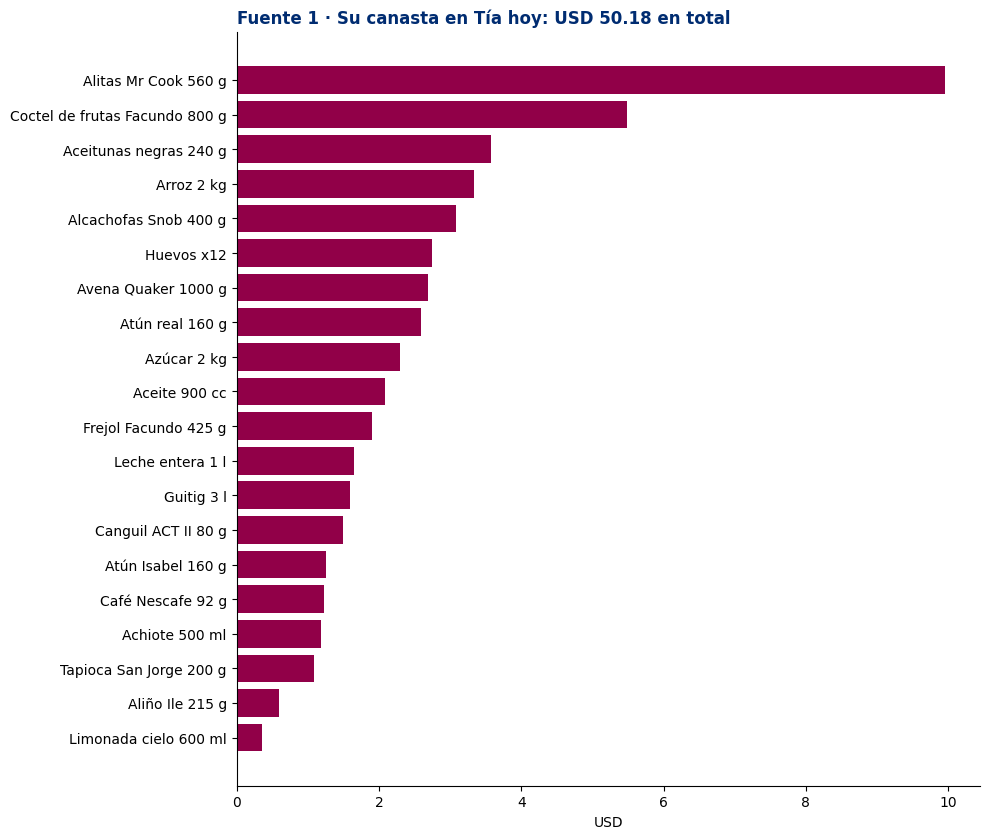

                      producto  precio_usd                  fuente
         Limonada cielo 600 ml        0.35 Tía · ficha de producto
               Aliño Ile 215 g        0.59 Tía · ficha de producto
       Tapioca San Jorge 200 g        1.09 Tía · ficha de producto
                Achiote 500 ml        1.19 Tía · ficha de producto
             Café Nescafe 92 g        1.23 Tía · ficha de producto
             Atún Isabel 160 g        1.25 Tía · ficha de producto
           Canguil ACT II 80 g        1.50 Tía · ficha de producto
                    Guitig 3 l        1.59 Tía · ficha de producto
              Leche entera 1 l        1.65 Tía · ficha de producto
          Frejol Facundo 425 g        1.90 Tía · ficha de producto
                 Aceite 900 cc        2.09 Tía · ficha de producto
                   Azúcar 2 kg        2.29 Tía · ficha de producto
               Atún real 160 g        2.59 Tía · ficha de producto
           Avena Quaker 1000 g        2.69 Tía · ficha de prod

In [3]:
#@title PASO 3 · Traer la Fuente 1 { display-mode: "form" }
#@markdown Pulsen el botón redondo y esperen (no escriben nada)
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json, os, subprocess, pandas as pd, matplotlib.pyplot as plt
if not _falta("decision.json", "Paso 2"):
    n = json.load(open("grupo.json"))["grupo"]
    programa = "tienda.py" if n == 1 else "sri.py"
    print(f"El robot {programa} está trabajando…\n")
    _r = subprocess.run(["python", programa], capture_output=True, text=True)
    print(_r.stdout)
    if _r.returncode != 0:
        print("⚠ El robot tuvo un problema. Tomen una captura de esta pantalla y avisen al profesor.")
    archivo = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if os.path.exists(archivo):
        t = pd.read_csv(archivo)
        if n == 1:
            t = t.sort_values("precio_usd")
            fig, ax = plt.subplots(figsize=(10, 0.35 * len(t) + 1.5))
            ax.barh(t["producto"], t["precio_usd"], color="#910048")
            ax.set_title(f"Fuente 1 · Su canasta en Tía hoy: USD {t['precio_usd'].sum():.2f} en total", loc="left", weight="bold", color="#002C71")
            ax.set_xlabel("USD")
        else:
            col = "provincia" if n == 2 else "actividad"
            t = t.sort_values("variacion_pct")
            fig, ax = plt.subplots(figsize=(10, 0.35 * len(t) + 1.5))
            ax.barh(t[col], t["variacion_pct"], color=["#EAAA00" if v else "#002C71" for v in t["vigilada"]])
            ax.axvline(0, color="#999999", lw=1)
            ax.set_title(f"Fuente 1 · Recaudación del SRI, variación % · {t['periodo'].iloc[0]} (amarillo = lo que vigilan)", loc="left", weight="bold", color="#002C71")
        ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()
        if n == 1:
            print(t[["producto", "precio_usd", "fuente"]].to_string(index=False))
        else:
            v = t.sort_values("variacion_pct", ascending=False)
            a0, a1 = [c for c in v.columns if c.startswith("recaudado_")]
            v = pd.DataFrame({col: v[col], f"millones USD {a0[-4:]}": (v[a0] / 1e6).round(1), f"millones USD {a1[-4:]}": (v[a1] / 1e6).round(1),
                              "variación %": v["variacion_pct"], "vigilan": ["✔ SÍ" if x else "" for x in v["vigilada"]]})
            print(v.to_string(index=False))
            print(f"\nFuente: {t['fuente'].iloc[0]} · periodo: {t['periodo'].iloc[0]}")
        print("\n✅ Paso 3 listo: la Fuente 1 ya está en la carpeta data.")
        print("🧩 Para el Paso 4: ahora el robot de la Fuente 2 le pregunta al Banco Mundial.")
    else:
        print("✋ Todavía no hay datos de la Fuente 1. Esperen un minuto y pulsen el botón redondo otra vez. Si se repite, tomen una captura y avisen al profesor.")

## PASO 4 · Traer la Fuente 2: el Banco Mundial

**🔗 Lo que ya tienen:** los datos de la Fuente 1 (Paso 3).

**🎯 En este paso:** el mismo robot de la clase (la ventanilla) le pregunta al Banco Mundial por dos indicadores de su sector, para ver el contexto del país.

**👆 Qué hacen:** pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> y esperen.

**👀 Qué deben ver:** `✔ LISTO` y un gráfico con dos líneas. Si aparece `⚠ … uso el RESPALDO`, está bien: sigan.

**🧩 Lo que se llevan al paso siguiente:** el archivo de la Fuente 2 en la carpeta `data`.

• Banco Mundial: «Inflación anual (%)» de Ecuador
    ← código 200: todo bien
    📄 página 1 de 3
    ← código 200: todo bien
    📄 página 2 de 3
    ← código 200: todo bien
    📄 página 3 de 3
• Banco Mundial: «Consumo de los hogares por persona, crecimiento (%)» de Ecuador
    ← código 200: todo bien
    📄 página 1 de 3
    ← código 200: todo bien
    📄 página 2 de 3
    ← código 200: todo bien
    📄 página 3 de 3

✔ LISTO: 52 datos de 1 API(s) guardados en data/indicadores_grupo.csv  [2026-09-30 17:32]



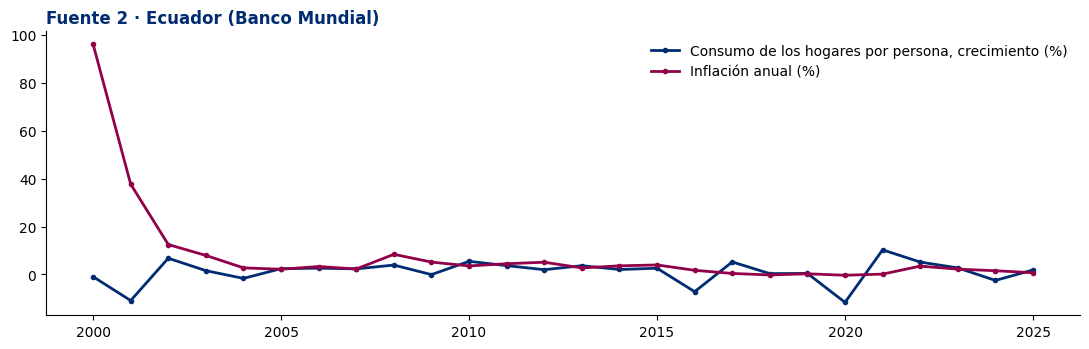

✅ Paso 4 listo: ya tienen las dos fuentes.
🧩 Para el Paso 5: van a comprobar con sus propios ojos que los datos son ciertos.


In [4]:
#@title PASO 4 · Traer la Fuente 2 { display-mode: "form" }
#@markdown Pulsen el botón redondo y esperen (no escriben nada)
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json, os, subprocess, pandas as pd, matplotlib.pyplot as plt
if not _falta("decision.json", "Paso 2"):
    n = json.load(open("grupo.json"))["grupo"]
    PREGUNTAS = {1: {"FP.CPI.TOTL.ZG": "Inflación anual (%)", "NE.CON.PRVT.PC.KD.ZG": "Consumo de los hogares por persona, crecimiento (%)"},
                 2: {"FS.AST.PRVT.GD.ZS": "Crédito al sector privado (% del PIB)", "FB.AST.NPER.ZS": "Morosidad bancaria (% de la cartera)"},
                 3: {"NY.GDP.MKTP.KD.ZG": "Crecimiento del PIB (%)", "NV.SRV.TOTL.KD.ZG": "Crecimiento de los servicios (%)"}}[n]
    json.dump(PREGUNTAS, open("indicadores_grupo.json", "w"), ensure_ascii=False)
    _r = subprocess.run(["python", "ventanilla.py", "--grupo"], capture_output=True, text=True)
    print(_r.stdout)
    if os.path.exists("data/indicadores_grupo.csv"):
        g = pd.read_csv("data/indicadores_grupo.csv")
        fig, ax = plt.subplots(figsize=(11, 3.6))
        for (nombre, d), color in zip(g.groupby("indicador"), ["#002C71", "#910048"]):
            ax.plot(d["anio"], d["valor"], marker="o", ms=3, lw=2, color=color, label=nombre)
        ax.set_title("Fuente 2 · Ecuador (Banco Mundial)", loc="left", weight="bold", color="#002C71")
        ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()
        print("✅ Paso 4 listo: ya tienen las dos fuentes.")
        print("🧩 Para el Paso 5: van a comprobar con sus propios ojos que los datos son ciertos.")
    else:
        print("✋ No llegaron datos. Esperen un minuto y pulsen el botón redondo otra vez. Si se repite, tomen una captura y avisen al profesor.")

## PASO 5a · ¿Qué comprobamos a mano?

**🔗 Lo que ya tienen:** las dos fuentes guardadas (Pasos 3 y 4).

**🎯 En este paso:** el cuaderno les da tres datos para comprobar en la fuente original. **Esto lo hacen ustedes, no la máquina.**

**👆 Qué hacen:** pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">, abran los enlaces que aparecen y anoten lo que encuentren.

**👀 Qué deben ver:** tres datos, cada uno con dónde comprobarlo.

**🧩 Lo que se llevan al paso siguiente:** lo que encontraron en cada fuente.

In [5]:
#@title PASO 5a · Qué comprobamos { display-mode: "form" }
#@markdown Pulsen el botón redondo y abran los enlaces
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json, pandas as pd
if _fuentes_listas():
    n = json.load(open("grupo.json"))["grupo"]
    if n == 1:
        t = pd.read_csv("data/canasta_tia.csv").sort_values("producto").head(3)
        print("Abran cada enlace y comparen el precio de la página con el que trajo el robot:\n")
        for i, r in enumerate(t.itertuples(), 1):
            print(f"  {i}. {r.producto}: el robot dice USD {r.precio_usd:.2f}\n     {r.url}\n")
        print("Ojo: si un precio no coincide, anótenlo: también es un hallazgo.")
    else:
        m = pd.read_csv("data/sri_total_mensual.csv", index_col=0)["millones_usd"]
        print("Recaudación TOTAL del país, mes a mes, según su archivo (millones de USD):\n")
        print(m.to_string())
        print("\n  1 y 2. Busquen en Google «SRI recaudación <mes> 2026» para DOS meses y comparen con lo que publicó el SRI o la prensa.")
        print("  3. Abran la página de datos del SRI y confirmen qué significa la columna VALOR_RECAUDADO:")
        print("     https://www.sri.gob.ec/datasets  (Valores recaudados, Diccionario de variables)")
    print("\n✅ Paso 5a listo. Escriban lo que encontraron en el Paso 5b.")

Abran cada enlace y comparen el precio de la página con el que trajo el robot:

  1. Aceite 900 cc: el robot dice USD 2.09
     https://www.tia.com.ec/supermercado/comestibles/aceites-y-vinagres/aceite-palma-de-oro-900-cc-257407000.html

  2. Aceitunas negras 240 g: el robot dice USD 3.57
     https://www.tia.com.ec/aceitunas-negras-gustadina-240-g-251837000.html

  3. Achiote 500 ml: el robot dice USD 1.19
     https://www.tia.com.ec/aceite-con-achiote-aliada-en-tu-ahorro-500-ml-259786000.html

Ojo: si un precio no coincide, anótenlo: también es un hallazgo.

✅ Paso 5a listo. Escriban lo que encontraron en el Paso 5b.


## PASO 5b · Anotar lo que comprobamos

**🔗 Lo que ya tienen:** lo que vieron en la fuente original (Paso 5a).

**🎯 En este paso:** dejan escrito qué compararon y si coincidió. De eso sale la etiqueta de sus datos.

**👆 Qué hacen:** para cada comprobación escriban **qué compararon** (por ejemplo `Arroz: robot 3.33, página 3.33`) y elijan el **resultado** en la lista. Luego pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué deben ver:** una tabla con sus tres comprobaciones y la etiqueta de los datos. Al final: `✅ Paso 5 listo`.

**🧩 Lo que se llevan al paso siguiente:** la etiqueta de sus datos: **[VERIFICADO]** o **[POR VERIFICAR]**.

In [6]:
#@title PASO 5b · Lo que comprobamos { display-mode: "form" }
#@markdown Escriban qué compararon, elijan el resultado y pulsen el botón redondo
COMPROBACION_1 = "Aceite 900 cc" #@param {type:"string"}
RESULTADO_1 = "Coincide" #@param ["Coincide", "No coincide", "No pudimos comprobarlo"]
COMPROBACION_2 = "Aceitunas negras 240 g" #@param {type:"string"}
RESULTADO_2 = "Coincide" #@param ["Coincide", "No coincide", "No pudimos comprobarlo"]
COMPROBACION_3 = "Achiote 500 ml" #@param {type:"string"}
RESULTADO_3 = "Coincide" #@param ["Coincide", "No coincide", "No pudimos comprobarlo"]
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json
if _fuentes_listas():
    filas = [(COMPROBACION_1, RESULTADO_1), (COMPROBACION_2, RESULTADO_2), (COMPROBACION_3, RESULTADO_3)]
    vacias = [str(i) for i, (c, _) in enumerate(filas, 1) if not c.strip()]
    for i, (c, r) in enumerate(filas, 1):
        et = "[VERIFICADO]" if r == "Coincide" else "[POR VERIFICAR]"
        print(f"{i}. {c.strip() or '___'}  ·  {r}  ·  {et}")
    etiqueta = "[VERIFICADO] en 3 valores" if all(r == "Coincide" for _, r in filas) else "[POR VERIFICAR] en parte"
    json.dump({"comprobaciones": filas, "etiqueta": etiqueta}, open("verificacion.json", "w"), ensure_ascii=False)
    print(f"\nEtiqueta de sus datos: {etiqueta}")
    if vacias:
        print(f"⚠ Falta escribir la comprobación {', '.join(vacias)}. Escríbanla y pulsen el botón redondo otra vez.")
    else:
        print("\n✅ Paso 5 listo: ya saben cuánto pueden confiar en sus datos.")
        print("🧩 Para el Paso 6: con los datos comprobados, van a interpretar las dos fuentes juntas.")

1. Aceite 900 cc  ·  Coincide  ·  [VERIFICADO]
2. Aceitunas negras 240 g  ·  Coincide  ·  [VERIFICADO]
3. Achiote 500 ml  ·  Coincide  ·  [VERIFICADO]

Etiqueta de sus datos: [VERIFICADO] en 3 valores

✅ Paso 5 listo: ya saben cuánto pueden confiar en sus datos.
🧩 Para el Paso 6: con los datos comprobados, van a interpretar las dos fuentes juntas.


## PASO 6a · Las dos fuentes juntas

**🔗 Lo que ya tienen:** las dos fuentes (Pasos 3 y 4), ya comprobadas (Paso 5).

**🎯 En este paso:** ven las dos fuentes lado a lado y la pregunta que su observatorio debe responder.

**👆 Qué hacen:** pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué deben ver:** dos gráficos, uno junto al otro, y la pregunta de su grupo.

**🧩 Lo que se llevan al paso siguiente:** la pregunta que van a responder en el Paso 6b.

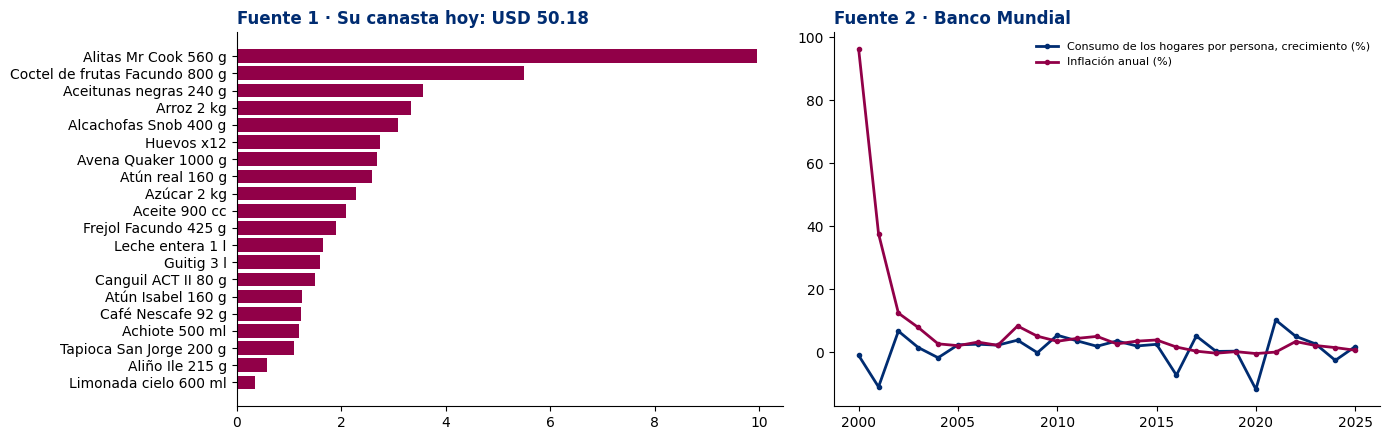

Último dato del Banco Mundial: Inflación anual (%): 0.7 (2025) · Consumo de los hogares por persona, crecimiento (%): 1.9 (2025)

📝 LA PREGUNTA DE SU GRUPO:
  ¿Nuestra canasta cuenta la misma historia que la inflación del Banco Mundial? ¿Qué producto pesa más en el bolsillo?

🧩 Para el Paso 6b: respóndanla con al menos dos cifras, una de cada fuente.


In [7]:
#@title PASO 6a · Las dos fuentes juntas { display-mode: "form" }
#@markdown Pulsen el botón redondo (no escriben nada)
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json, pandas as pd, matplotlib.pyplot as plt
if _fuentes_listas():
    n = json.load(open("grupo.json"))["grupo"]
    bm = pd.read_csv("data/indicadores_grupo.csv")
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5))
    if n == 1:
        c = pd.read_csv("data/canasta_tia.csv").sort_values("precio_usd")
        a1.barh(c["producto"], c["precio_usd"], color="#910048")
        a1.set_title(f"Fuente 1 · Su canasta hoy: USD {c['precio_usd'].sum():.2f}", loc="left", weight="bold", color="#002C71")
    else:
        t = pd.read_csv("data/sri_resumen.csv"); t = t[t["vigilada"]].sort_values("variacion_pct")
        col = "provincia" if n == 2 else "actividad"
        a1.barh(t[col], t["variacion_pct"], color=["#910048" if v < 0 else "#002C71" for v in t["variacion_pct"]])
        a1.axvline(0, color="#999999", lw=1)
        a1.set_title("Fuente 1 · SRI: variación % de lo que vigilan", loc="left", weight="bold", color="#002C71")
        print(t[[col, "variacion_pct"]].to_string(index=False) + "\n")
    for (nombre, d), color in zip(bm.groupby("indicador"), ["#002C71", "#910048"]):
        a2.plot(d["anio"], d["valor"], marker="o", ms=3, lw=2, color=color, label=nombre)
    a2.set_title("Fuente 2 · Banco Mundial", loc="left", weight="bold", color="#002C71"); a2.legend(frameon=False, fontsize=8)
    for a in (a1, a2): a.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    ultimo = bm.sort_values("anio").groupby("indicador").tail(1)
    print("Último dato del Banco Mundial: " + " · ".join(f"{r.indicador}: {r.valor:.1f} ({r.anio})" for r in ultimo.itertuples()))
    print("\n📝 LA PREGUNTA DE SU GRUPO:")
    print({1: "  ¿Nuestra canasta cuenta la misma historia que la inflación del Banco Mundial? ¿Qué producto pesa más en el bolsillo?",
           2: "  ¿Las provincias que vigilamos se mueven igual que el crédito y la morosidad del país?",
           3: "  ¿Las actividades que vigilamos crecen más o menos que la economía (PIB)? ¿Cuál preocupa?"}[n])
    print("\n🧩 Para el Paso 6b: respóndanla con al menos dos cifras, una de cada fuente.")

## PASO 6b · Nuestra interpretación

**🔗 Lo que ya tienen:** las dos fuentes lado a lado y la pregunta de su grupo (Paso 6a).

**🎯 En este paso:** responden la pregunta con sus palabras y dicen qué **no** permite afirmar este dato.

**👆 Qué hacen:** 1. En **INTERPRETACION** respondan la pregunta en 3 o 4 frases, **con al menos dos cifras (una de cada fuente)**.
2. En **LO_QUE_NO_PERMITE_AFIRMAR** escriban un límite del dato (por ejemplo: la Fuente 1 es de un solo día, o viene del respaldo).
3. Pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué deben ver:** su interpretación y `✅ Paso 6 listo`. Si falta una cifra, el cuaderno les avisa.

**🧩 Lo que se llevan al paso siguiente:** la interpretación del observatorio.

In [8]:
#@title PASO 6b · Nuestra interpretación { display-mode: "form" }
#@markdown Escriban y pulsen el botón redondo
INTERPRETACION = "No cuentan la misma historia: mientras la canasta actual suma $50.18 y tiene a las Alitas Mr Cook 560g como el producto de mayor peso (casi $10), la inflación del Banco Mundial muestra una estabilidad generalizada con apenas 0.7 % para 2025. La canasta refleja el costo total de una compra puntual de consumo, a diferencia del indicador macroeconómico general" #@param {type:"string"}
LO_QUE_NO_PERMITE_AFIRMAR = "La fuente 1 registra los datos de un solo día (\"su canasta hoy\"), por lo que no permite medir variaciones ni calcular la inflación real en el tiempo de este grupo de productos" #@param {type:"string"}
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json, re
if not _falta("verificacion.json", "Paso 5b"):
    print(f"Interpretación: {INTERPRETACION.strip() or '___'}\n")
    print(f"Lo que el dato todavía no permite afirmar: {LO_QUE_NO_PERMITE_AFIRMAR.strip() or '___'}")
    json.dump({"interpretacion": INTERPRETACION.strip(), "limite": LO_QUE_NO_PERMITE_AFIRMAR.strip()}, open("interpretacion.json", "w"), ensure_ascii=False)
    if not INTERPRETACION.strip() or not LO_QUE_NO_PERMITE_AFIRMAR.strip():
        print("\n⚠ Falta llenar un recuadro. Escríbanlo y pulsen el botón redondo otra vez.")
    elif len(re.findall(r"\d+[.,]?\d*", INTERPRETACION)) < 2:
        print("\n⚠ Su interpretación tiene menos de dos cifras. Agreguen una de cada fuente y pulsen el botón redondo otra vez.")
    else:
        print("\n✅ Paso 6 listo: el observatorio ya dice qué significan sus datos.")
        print("🧩 Para el Paso 7: dejan constancia de quién hizo qué.")

Interpretación: No cuentan la misma historia: mientras la canasta actual suma $50.18 y tiene a las Alitas Mr Cook 560g como el producto de mayor peso (casi $10), la inflación del Banco Mundial muestra una estabilidad generalizada con apenas 0.7 % para 2025. La canasta refleja el costo total de una compra puntual de consumo, a diferencia del indicador macroeconómico general

Lo que el dato todavía no permite afirmar: La fuente 1 registra los datos de un solo día ("su canasta hoy"), por lo que no permite medir variaciones ni calcular la inflación real en el tiempo de este grupo de productos

✅ Paso 6 listo: el observatorio ya dice qué significan sus datos.
🧩 Para el Paso 7: dejan constancia de quién hizo qué.


## PASO 7 · Quién hizo qué

**🔗 Lo que ya tienen:** todo el trabajo del equipo (Pasos 1 a 6).

**🎯 En este paso:** dejan constancia de qué hizo cada integrante y si usaron IA. El cuaderno arma la ficha final del equipo y el archivo `FUENTES.md` para la casa.

**👆 Qué hacen:** 1. En **QUIEN_HIZO_QUE** escriban, para cada integrante, qué parte hizo (por ejemplo `Ana: pasos 1 a 3; Luis: paso 5; …`).
2. En **USO_DE_IA** escriban qué IA usaron y para qué, o déjenlo en *No usamos IA*.
3. Pulsen <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué deben ver:** la ficha completa del equipo y `✅ Paso 7 listo`.

**🧩 Lo que se llevan al paso siguiente:** la ficha del equipo, lista para imprimir.

In [10]:
#@title PASO 7 · Quién hizo qué { display-mode: "form" }
#@markdown Escriban y pulsen el botón redondo
QUIEN_HIZO_QUE = "ZARA: PASO 1 Y 2. SARA: PASO 3 AL 5. GABRIEL: PASO 5. NAYELI: PASO 6." #@param {type:"string"}
USO_DE_IA = "Si usamos IA para analizar la tabla de precios de los productos" #@param {type:"string"}
def _falta(que, paso):
    import os
    if not os.path.exists(que):
        print(f"✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del {paso}.")
        return True
    return False
def _fuentes_listas():
    import os, json
    if _falta("grupo.json", "Paso 1"):
        return False
    n = json.load(open("grupo.json"))["grupo"]
    f1 = "data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv"
    if not os.path.exists(f1):
        print("✋ Todavía falta la Fuente 1: pulsen el botón redondo del Paso 3 hasta que diga «Paso 3 listo».")
        print("   Si el Paso 3 no logra traer los datos, tomen una captura y avisen al profesor.")
        return False
    return not _falta("data/indicadores_grupo.csv", "Paso 4")

import json, pandas as pd
if not _falta("interpretacion.json", "Paso 6b"):
    g = json.load(open("grupo.json")); n = g["grupo"]
    dec, ver, inter = json.load(open("decision.json")), json.load(open("verificacion.json")), json.load(open("interpretacion.json"))
    f1 = pd.read_csv("data/canasta_tia.csv" if n == 1 else "data/sri_resumen.csv")
    f2 = pd.read_csv("data/indicadores_grupo.csv")
    print("═" * 70); print(f"  FICHA DEL EQUIPO · {g['nombre']}"); print("═" * 70)
    print(f"Integrantes: {g['integrantes'] or '___'}\n")
    print(f"Qué vigilamos: {', '.join(map(str, dec['eleccion']))}")
    print(f"Por qué: {dec['por_que'] or '___'}\n")
    print(f"Fuente 1: {f1['fuente'].iloc[0]} · {len(f1)} filas · captura {f1['fecha_captura'].iloc[0]}")
    print(f"Fuente 2: {f2['fuente'].iloc[0]} · {f2['indicador'].nunique()} indicadores, {f2['anio'].min()} a {f2['anio'].max()}")
    print(f"Comprobación a mano: {ver['etiqueta']}\n")
    print(f"Interpretación: {inter['interpretacion']}")
    print(f"Límite: {inter['limite']}\n")
    print(f"Quién hizo qué: {QUIEN_HIZO_QUE.strip() or '___'}")
    print(f"Uso de IA: {USO_DE_IA.strip() or '___'}")
    print("═" * 70)
    como = "el robot tienda.py lee cada ficha de producto" if n == 1 else ("respaldo del profesor, sacado del archivo oficial del SRI (el portal bloquea a Colab)" if "respaldo" in f1["fuente"].iloc[0] else "API del portal de datos abiertos y descarga del SRI")
    open("FUENTES.md", "w", encoding="utf-8").write("\n".join([
        f"# De dónde viene cada dato · {g['nombre']}", "",
        "| Fuente | Qué trae | Cómo llega | Última captura | Etiqueta |", "|---|---|---|---|---|",
        f"| {f1['fuente'].iloc[0]} | {len(f1)} filas | {como} | {f1['fecha_captura'].iloc[0]} | {ver['etiqueta']} |",
        f"| {f2['fuente'].iloc[0]} | {f2['indicador'].nunique()} indicadores, {f2['anio'].min()}–{f2['anio'].max()} | API pública del Banco Mundial (ventanilla.py) | {f2['fecha_captura'].iloc[0]} | [VERIFICADO] |", "",
        f"**Integrantes:** {g['integrantes']}  ", f"**Quién hizo qué:** {QUIEN_HIZO_QUE.strip()}  ", f"**Uso de IA:** {USO_DE_IA.strip()}", ""]))
    if not QUIEN_HIZO_QUE.strip():
        print("⚠ Falta QUIEN_HIZO_QUE. Escríbanlo y pulsen el botón redondo otra vez.")
    else:
        print("✅ Paso 7 listo. Sigan con el Paso 8: guardar y entregar.")

══════════════════════════════════════════════════════════════════════
  FICHA DEL EQUIPO · Grupo 1 · El bolsillo del ecuatoriano
══════════════════════════════════════════════════════════════════════
Integrantes: ZARA TIGUA, GABRIEL CUPACAN, NAYELI LIMA Y SARA SÁNCHEZ

Qué vigilamos: Arroz 2 kg, Aceite 900 cc, Azúcar 2 kg, Leche entera 1 l, Huevos x12, Achiote 500 ml, Aceitunas negras 240 g, Limonada cielo 600 ml, Guitig 3 l, Alcachofas Snob 400 g, Aliño Ile 215 g, Alitas Mr Cook 560 g, Atún real 160 g, Atún Isabel 160 g, Avena Quaker 1000 g, Café Nescafe 92 g, Canguil ACT II 80 g, Coctel de frutas Facundo 800 g, Tapioca San Jorge 200 g, Frejol Facundo 425 g
Por qué: Escogimos esas provincias ya que son las más importantes del Ecuador y además tienen bastante actividad comercial. Además, seleccionamos provincias de diferentes regiones para poder hacer una comparación más equitativa

Fuente 1: Tía · ficha de producto · 20 filas · captura 2026-09-30 17:31
Fuente 2: Banco Mundial · 2 ind

## PASO 8 · Guardar y entregar

**🔗 Lo que ya tienen:** la ficha del equipo (Paso 7) y sus datos en la carpeta `data`.

**🎯 En este paso:** entregan **dos cosas**, y lo hace **una sola persona del equipo**: el **PDF** del cuaderno en Canvas y los **datos** en la casa del equipo en GitHub.

### A · El PDF, en Canvas
1. Menú **Archivo**, opción **Imprimir**. En **Destino** elijan **Guardar como PDF** y pulsen **Guardar**. El PDF queda en **Descargas**.
2. En Canvas, abran la tarea **P1-TG-4 · Dos fuentes entrando** y pulsen **Entregar tarea**.
3. Pulsen **Cargar archivo**, elijan el PDF y pulsen **Entregar tarea**.
4. **Qué deben ver:** Canvas dice **Entregado**.

### B · Los datos, en la casa del equipo en GitHub
1. Pulsen el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo. Se descarga a su computador el archivo **`deber_grupal_semana4.zip`** (un paquete con sus datos). Si el navegador pregunta, pulsen **Permitir** o **Conservar**.
2. Vayan a **Descargas**, hagan **clic derecho** sobre `deber_grupal_semana4.zip` y elijan **Extraer todo…** y luego **Extraer**. Se abre una carpeta nueva con el mismo nombre. *(En Mac: doble clic sobre el zip.)*
3. Menú **Archivo** de Colab, opción **Descargar**, luego **Descargar .ipynb**. Muevan ese archivo a la carpeta del paso 2.
4. Abran la casa de su equipo (haga clic en la suya):
   [observatorio-g01](https://github.com/uide-programacion-inteligencia-mercados/observatorio-g01) · [observatorio-g02](https://github.com/uide-programacion-inteligencia-mercados/observatorio-g02) · [observatorio-g03](https://github.com/uide-programacion-inteligencia-mercados/observatorio-g03)
5. Arriba, botón **Add file**, luego **Upload files**.
6. En la carpeta del paso 2, seleccionen **todo lo que hay adentro** (Ctrl + A) y arrástrenlo a la página de GitHub. *(Se arrastra lo que está dentro de la carpeta, no el .zip.)*
7. Esperen a que aparezca la lista de archivos. Abajo escriban `Hito 1: dos fuentes` y pulsen el botón verde **Commit changes**.
8. **Qué deben ver:** en la página de la casa, la carpeta **data** (con dos archivos `.csv`), el archivo **FUENTES.md** y su cuaderno `.ipynb`.

*Si GitHub no les deja subir, usen la cuenta de otro integrante del equipo que sí haya aceptado la invitación a la organización.*

In [11]:
#@title PASO 8 · Descargar el paquete de datos { display-mode: "form" }
#@markdown Pulsen el botón redondo (se descarga deber_grupal_semana4.zip)
import os, zipfile
if not os.path.exists("FUENTES.md"):
    print("✋ Todavía no pueden hacer este paso: primero pulsen el botón redondo del Paso 7.")
else:
    with zipfile.ZipFile("deber_grupal_semana4.zip", "w", zipfile.ZIP_DEFLATED) as z:
        for f in ["FUENTES.md", "tienda.py", "sri.py", "ventanilla.py"] + [f for f in ("canasta.txt",) if os.path.exists(f)]:
            z.write(f)
        for f in sorted(os.listdir("data")):
            if os.path.isfile(os.path.join("data", f)):
                z.write(os.path.join("data", f))
    try:
        from google.colab import files
        files.download("deber_grupal_semana4.zip")
        print("✔ Se descargó deber_grupal_semana4.zip (está en la carpeta Descargas de su computador).")
    except ImportError:
        print("✔ Paquete creado: deber_grupal_semana4.zip")
    print("✅ Ahora sigan los pasos B.2 a B.8 de arriba.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔ Se descargó deber_grupal_semana4.zip (está en la carpeta Descargas de su computador).
✅ Ahora sigan los pasos B.2 a B.8 de arriba.
